In [5]:
import sys
sys.path.append("..")
import numpy as np
from utils.parse import create_perf_df_from_trace, parse_ops_one_iter
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize, LogNorm


In [6]:
expert_res_file = "../results/2025-10-28-22-55-22_qwen-moe/trace_qwen1.5-moe-a2.7b-q4_k_f16_t2_p5_moe.npy"
trace_csv = "../results/2025-10-28-22-55-22_qwen-moe/trace_qwen1.5-moe-a2.7b-q4_k_f16_t2_p5.csv"
# expert_res_file = "experiments/2025-10-29-13-37-57_qwen-moe/trace_qwen1.5-moe-a2.7b-q4_k_f16_t2_p5_moe.npy"
# trace_csv = "experiments/2025-10-29-13-37-57_qwen-moe/trace_qwen1.5-moe-a2.7b-q4_k_f16_t2_p5.csv"
exp_res = np.load(expert_res_file)

In [7]:
exp_res.shape

(101, 144, 4)

/tmp/ipykernel_34472/858479912.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


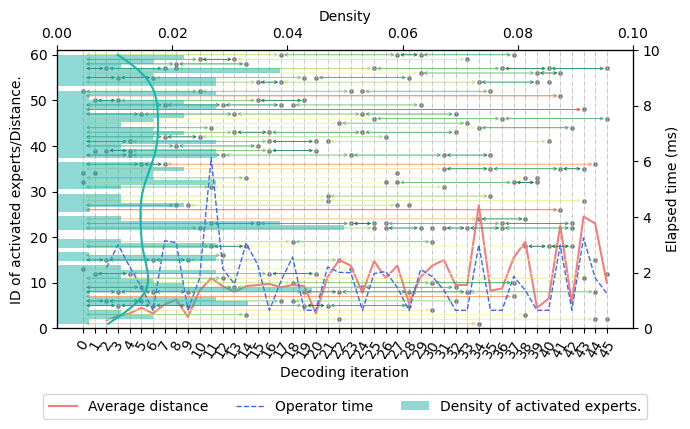

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
colormap = plt.get_cmap("RdYlGn_r")
norm = Normalize(vmin=1, vmax=50)
df = create_perf_df_from_trace(trace_csv)
n_decode_total = df["count_decode"].max()
exp_id_to_last_pos = defaultdict(lambda: 0)
exp_id_to_freq = defaultdict(lambda: 0)
diff_sum_iters = []
elapsed_time_iters = []
start_iter = 2
end_iter = 45
dfs_iter = []
for i in range(end_iter + 1):
    df_iter = parse_ops_one_iter(df, n_iter=i)
    dfs_iter.append(df_iter)
    elapsed_time_iters.append(df_iter[df_iter["name"] == "ffn_moe_up-0"].iloc[0]["elapsed_time"])
    # print(exp_res[i, 0])
    pos_diff = []
    for exp in exp_res[i, 0]:
        exp += 1
        diff = i - exp_id_to_last_pos[exp]
        exp_id_to_freq[exp] += 1
        ax.scatter(i, exp, marker="o", color="dimgrey", s=6, alpha=0.7)
        if i >= start_iter:
            if diff > 1:
                ax.annotate("", xy=(i, exp), xytext=(exp_id_to_last_pos[exp], exp), arrowprops=dict(arrowstyle='<->', color=colormap(norm(diff)), linewidth=0.6, mutation_scale=5))
        #     elif diff == 1:
        #         ax.scatter(i, exp, marker="x", color="red", s=5)
        pos_diff.append(diff)
        exp_id_to_last_pos[exp] = i
    diff_sum_iters.append(sum(pos_diff) / len(pos_diff))
ax.plot(np.arange(start_iter, end_iter + 1), diff_sum_iters[start_iter:end_iter + 1], color="lightcoral", label="Average distance")
ax.set_ylim([0, 61])
# ax.set_xlim
ax.grid(axis="x", linewidth=0.5, linestyle="-.")
ax.set_ylabel("ID of activated experts/Distance.")
ax.set_xticks(np.arange(end_iter + 1))
ax.set_xticklabels(np.arange(end_iter + 1), rotation=60)
ax_1 = ax.twinx()
ax_1.plot(np.arange(start_iter, end_iter + 1), elapsed_time_iters[start_iter:end_iter + 1], color="royalblue", linewidth=1, label="Operator time", linestyle="--")
ax_1.set_ylim(0, 10)
ax_1.set_ylabel("Elapsed time (ms)")
ax_2 = ax.twiny()
# ax_2.barh(np.arange(1, 61), [exp_id_to_freq[e] for e in range(1, 61)])
samples = []
for e in range(1, 61):
    samples.extend([e] * exp_id_to_freq[e])
# distribute = [exp_id_to_freq[e] * [e] for e in range(1, 61)]
# ax.plot([exp_id_to_freq[e] for e in range(1, 61)], np.arange(1, 61))
sns.histplot(y=samples, ax=ax_2, kde=True, linewidth=0.5, linestyle="-.", color="lightseagreen", stat="density", bins=60, edgecolor=None, label="Density of activated experts.")
ax_2.set_xlabel("Density")
ax_2.set_xlim([0, 0.1])
ax.set_xlabel("Decoding iteration")
# print(samples)
fig.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, 0.02))
fig.tight_layout()
fig.show()
# fig.savefig("figures/moe_one_op.pdf", bbox_inches="tight")

/tmp/ipykernel_34472/1802416172.py:39: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


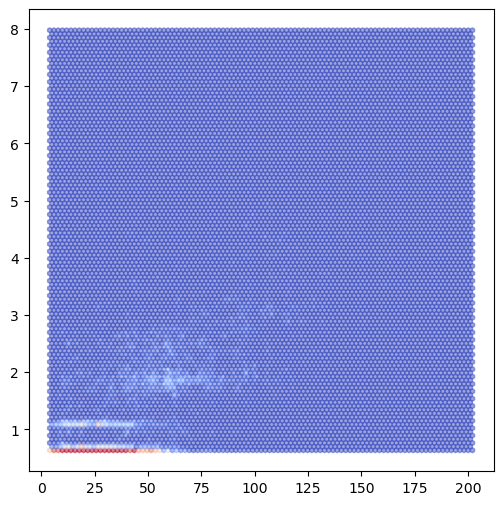

In [14]:
fig, ax = plt.subplots(figsize=(6,6))
op_names = ["ffn_moe_up", "ffn_moe_gate", "ffn_moe_down"]
n_layers = 24
op_to_exp_to_pos = defaultdict(lambda: defaultdict(lambda: 0))
end_iter = 100
start_iter = 2
colormap = plt.get_cmap("coolwarm")
norm = Normalize(vmin=0, vmax=n_decode_total)
cmaps = ["Greens", "Blues", "Oranges"]
colors = ["green", "blue", "orange"]
t_all = []
diff_all = []
for i in range(n_decode_total):
    
    for i_op, op in enumerate(op_names):
        df_iter = parse_ops_one_iter(df, n_iter=i)
        for i_layer in range(n_layers):
            op_name = f"{op}-{i_layer}"
            t = df_iter[df_iter["name"] == op_name].iloc[0]["elapsed_time"]
            pos_diff = []
            for exp in exp_res[i, 6 * i_layer]:
                pos_diff.append(i - op_to_exp_to_pos[op_name][exp])
                op_to_exp_to_pos[op_name][exp] = i
            avg_diff = sum(pos_diff)
            if i > start_iter:
                t_all.append(t)
                diff_all.append(avg_diff)
            # ax.scatter(avg_diff, t)

t_all_np = np.array(t_all)
diff_all_np = np.array(diff_all)
diff_all_np = diff_all_np[t_all_np < 8]
t_all_np = t_all_np[t_all_np < 8]
ax.hexbin(diff_all_np, t_all_np, gridsize=100, norm=Normalize(vmin=1, vmax=50), cmap="coolwarm", alpha=0.5)
    # ax.scatter(diff_all_np, t_all_np, s=5, color=colormap(norm(i)))
# ax.set_ylim([0, 4])
# ax.color
# fig.legend()
fig.show()

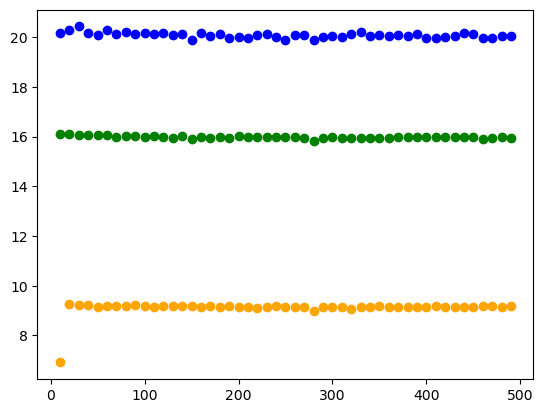

In [48]:
import os
import json
from glob import glob
model_color = {
    "Gemma2-2B": "orange",
    "LLaMA3.2-1B": "blue",
    "Qwen2-1.5B": "green"
}
# results = defaultdict(list)
prefill_dir = "exp_prefill"
p_speed = []
n_prompts = []
for exp_dir in os.listdir(prefill_dir):
    metric_json = f"{prefill_dir}/{exp_dir}/l3d_cache_refill/metrics.json"
    config_json = list(glob(f"{prefill_dir}/{exp_dir}/config/*.json"))[0]
    with open(metric_json) as json_file:
        metric = json.load(json_file)
        # print(metric["prefill_speed"])
        p_s = metric["prefill_speed"]
        p_speed.append(p_s)
    with open(config_json) as json_file:
        config = json.load(json_file)
        n_p = config["llama-cli"]["n_prompt"]
        # print(config["llama-cli"]["n_prompt"])
        n_prompts.append(n_p)
    plt.scatter(n_p, p_s, color=model_color[config["llama-cli"]["model"]], label=config["llama-cli"]["model"])
# plt.legend()
# print(n_prompts)
# plt.scatter(n_prompts, p_speed)